# bar — GPU-accelerated bar chart

Renders vertical bars using SDF rounded rectangles.

```
bar(x_or_data, y=None, *, x_col, y_col, color, bar_width, opacity,
    width, height, padding, interactive) -> np.ndarray | None
```

`x` categories are expected as numeric indices or sequential values; `y` is bar height.

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
import justviz as jv

## 1 — Simple 8-bar chart

bar: 8 bars, 800×500, render 268.4ms


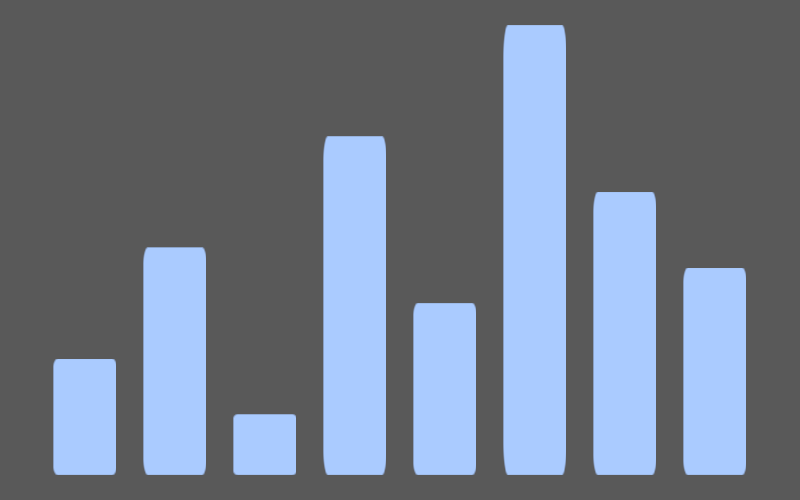

In [2]:
categories = np.arange(8, dtype=np.float32)
values = np.array([23, 45, 12, 67, 34, 89, 56, 41], dtype=np.float32)

img = jv.bar(categories, values, color=(0.4, 0.6, 1.0), bar_width=0.7, width=800, height=500)
display(Image.fromarray(img, mode='RGBA'))

## 2 — Many bars (50) with warm color

bar: 50 bars, 1200×500, render 3.0ms


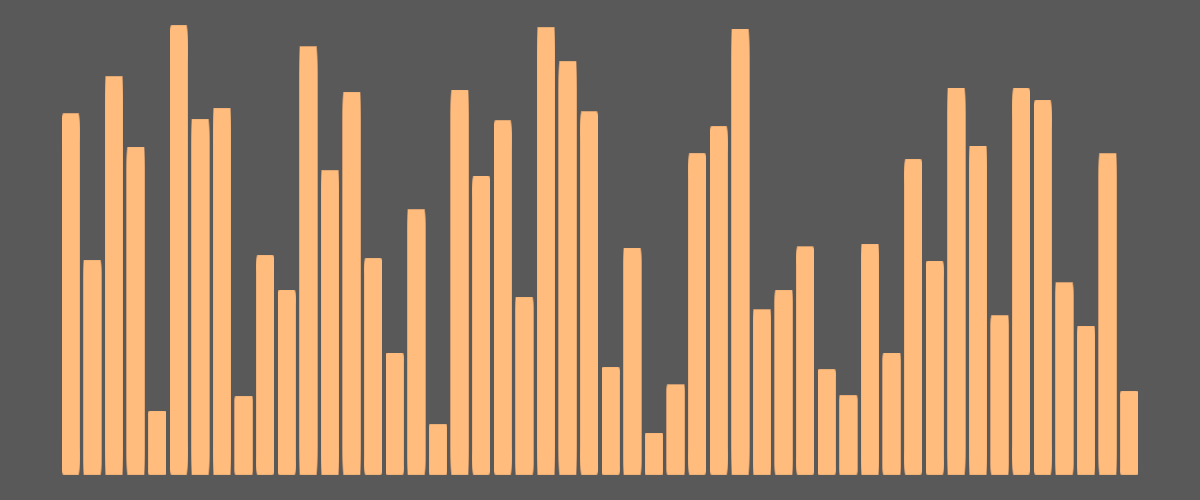

In [3]:
rng = np.random.default_rng(42)
n = 50
x = np.arange(n, dtype=np.float32)
y = rng.uniform(5, 100, n).astype(np.float32)

img = jv.bar(x, y, color=(1.0, 0.5, 0.2), bar_width=0.85, width=1200, height=500)
display(Image.fromarray(img, mode='RGBA'))

## 3 — From a pandas DataFrame

bar: 12 bars, 900×500, render 3.2ms


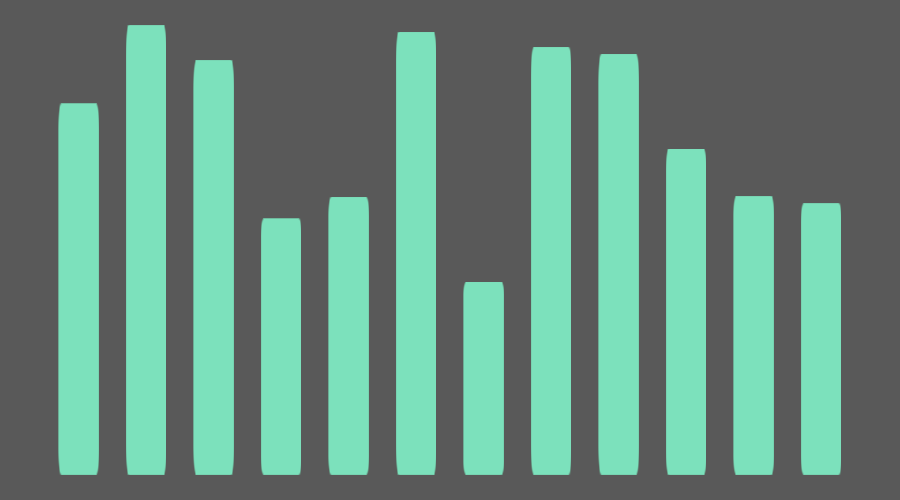

In [4]:
rng = np.random.default_rng(7)
months = np.arange(12, dtype=np.float32)  # 0..11 as category indices
df = pd.DataFrame({
    "month":   months,
    "revenue": rng.uniform(80, 200, 12).astype(np.float32),
})

img = jv.bar(df, x_col="month", y_col="revenue",
             color=(0.2, 0.75, 0.5), bar_width=0.6, width=900, height=500)
display(Image.fromarray(img, mode='RGBA'))

## 4 — From a Parquet file

bar: 20 bars, 900×500, render 2.5ms


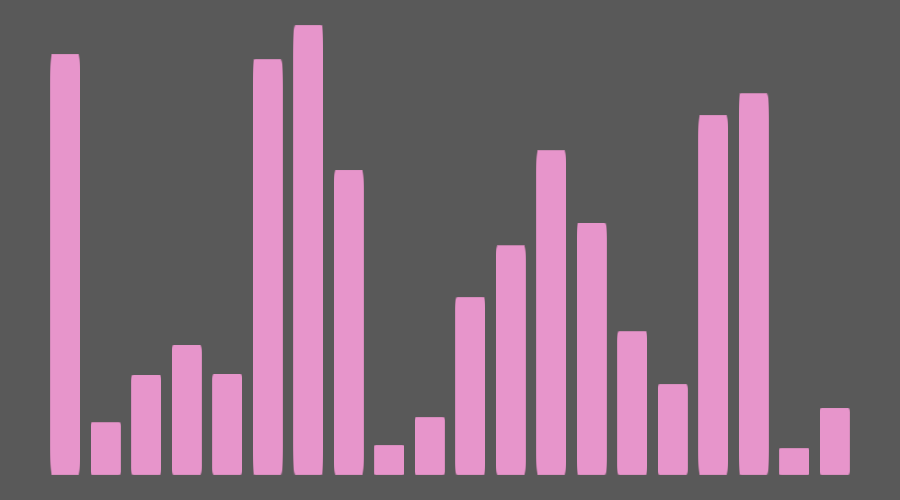

In [5]:
import pyarrow as pa
import pyarrow.parquet as pq

rng = np.random.default_rng(3)
table = pa.table({
    "bucket": np.arange(20, dtype=np.float32),
    "count":  rng.integers(10, 500, 20).astype(np.float32),
})
pq.write_table(table, "/tmp/bar_data.parquet")

img = jv.bar("/tmp/bar_data.parquet", x_col="bucket", y_col="count",
             color=(0.8, 0.3, 0.6), bar_width=0.75, width=900, height=500)
display(Image.fromarray(img, mode='RGBA'))

## 5 — Narrow vs wide bars (`bar_width`)

narrow (0.3)
bar: 10 bars, 700×400, render 2.6ms


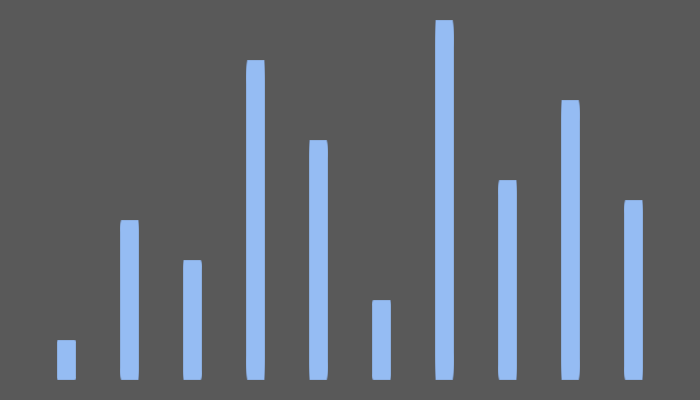

medium (0.6)
bar: 10 bars, 700×400, render 2.0ms


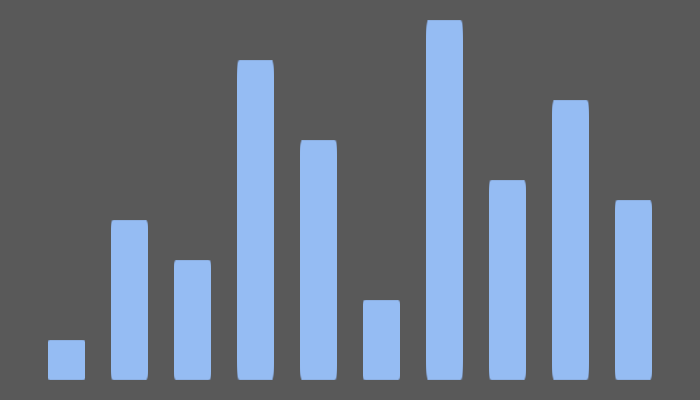

wide (0.95)
bar: 10 bars, 700×400, render 1.8ms


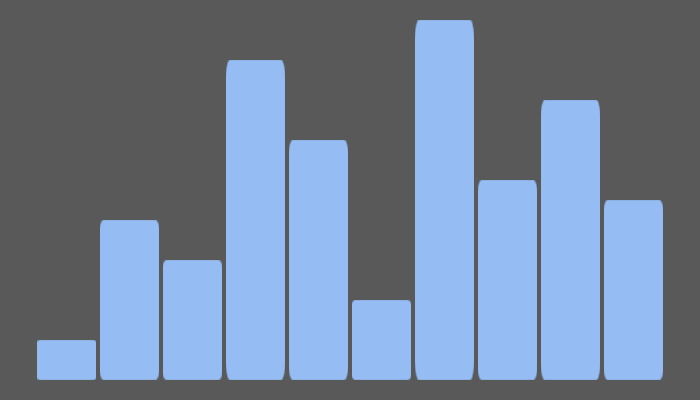

In [6]:
x = np.arange(10, dtype=np.float32)
y = np.array([10, 40, 30, 80, 60, 20, 90, 50, 70, 45], dtype=np.float32)

for bw, label in [(0.3, "narrow (0.3)"), (0.6, "medium (0.6)"), (0.95, "wide (0.95)")]:
    print(label)
    img = jv.bar(x, y, color=(0.3, 0.5, 0.9), bar_width=bw, width=700, height=400)
    display(Image.fromarray(img, mode='RGBA'))